In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy 
from pfapack import pfaffian as pf
import h5py
import time
import os
import traceback

In [3]:
def get_eta_B(A):
    """Takes in a skew-symmetric matrix and returns eta and B as defined in the pfaffian paper in eq.(4)"""

    B = scipy.linalg.expm(-A)

    sinhA = scipy.linalg.sinhm(A/4)

    bdim = B.shape[0]

    M = np.zeros((2*bdim, 2*bdim), dtype = np.complex128)

    M[0:bdim, 0:bdim] = np.sqrt(2) * sinhA
    M[bdim:,0:bdim]   = np.identity(bdim)
    M[0:bdim,bdim:]   = -np.identity(bdim)
    M[bdim:,bdim:]    = np.sqrt(2) * sinhA

    eta = np.power(-1,bdim//2) * pf.pfaffian(M)

    return eta, B

def get_correlator_and_action(h5_name: str, dex: int):

    with h5py.File(h5_name, "r") as f:
        N_cfg = len(f["data"].keys())
        if dex >= N_cfg:
            print("Index too large")
            return -1
        
        path_corr   = "data/" + str(dex) + "/correlators"
        path_action = "data/" + str(dex) + "/action"

        correlator = f[path_corr][:]
        action     = f[path_action][()]
    return correlator, action

def read_correlator_file(filename, model):
    """Careful, this returns the weighted correlators, so the correlators multiplied by the phases"""
    with h5py.File(filename, 'r') as f:

        N_samples = len(f['/data'])

    correlator_samples = np.zeros((2*model.L, 2*model.L, model.Ntau+1, N_samples), dtype = np.complex128)
    phases             = np.empty(N_samples, dtype = np.complex128)
    action = 0

    for i in range(N_samples):

        correlator_samples[:,:,:,i], action = get_correlator_and_action(filename, i)
        phases[i]                           = np.exp(-1j*action.imag)
        correlator_samples[:,:,:,i]         = correlator_samples[:,:,:,i] * phases[i]

    return correlator_samples, phases

def bootstrap_reweighting(samples, phases, binsize, N_boot, rng, correlated_r_idx = None):

    dtype = samples.dtype

    N_bins = samples.shape[-1]//binsize

    if N_bins < 2:
        raise ValueError("Need at least two bins for a bootstrap error estimate.")


    sample_size = N_bins*binsize

    samples = samples[...,:sample_size]
    phases  = phases[...,:sample_size]

    samples = samples.reshape(*samples.shape[:-1], N_bins, binsize)
    phases = phases.reshape(*phases.shape[:-1], N_bins, binsize)

    sample_bin_means = samples.mean(axis = -1)
    phases_bin_means = phases.mean(axis = -1)

    empiric_means = np.empty((*sample_bin_means.shape[:-1], N_boot), dtype = dtype)
    empiric_means_phase = np.empty((*phases_bin_means.shape[:-1], N_boot), dtype = dtype)

    if correlated_r_idx is None:
        r_idx = rng.integers(low = 0, high = N_bins, size = N_bins*N_boot).reshape(N_bins,N_boot)
    else:
        r_idx = correlated_r_idx

    for i in range(N_boot):

        empiric_means[...,i] = np.mean(sample_bin_means[...,r_idx[:,i]], axis = -1)
        empiric_means_phase[...,i] = np.mean(phases_bin_means[...,r_idx[:,i]], axis = -1)

    reweighted_mean = (sample_bin_means).mean(axis = -1)/phases_bin_means.mean()
    reweighted_std  = np.std((empiric_means/empiric_means_phase).real, axis = -1, ddof = 1) + 1j* np.std((empiric_means/empiric_means_phase).imag, axis = -1, ddof = 1)
    phase_mean      = phases.mean()
    phase_std       = phases.real.std() + 1j*phases.imag.std()

    return reweighted_mean, reweighted_std, phase_mean, phase_std

def get_dirac_correlators(correlators):

    L = correlators.shape[0]//2

    dirac_correlators = 0.25*(correlators[:L,:L] - 1j * correlators[:L,L:] +1j * correlators[L:,:L] + correlators[L:,L:])

    return dirac_correlators

def get_maj_k_correlators(correlators, model):

    H0 = model.A_odd / (4*model.dtau)

    E, U = scipy.linalg.eigh(H0)

    UH   = U.conj().T

    C_maj_k = np.einsum("ia,abkl,bj->ijkl", UH, correlators, U)

    return C_maj_k

def get_anomalous_dirac_correlators(correlators):
    
    L = correlators.shape[0]//2
                        #                       eta_eta                   eta_gam                  gam_eta              gam_gam
    a_adag_dirac_correlators    = 0.25*(correlators[:L,:L] - 1j * correlators[:L,L:] + 1j * correlators[L:,:L] + correlators[L:,L:])
    adag_a_dirac_correlators    = 0.25*(correlators[:L,:L] + 1j * correlators[:L,L:] - 1j * correlators[L:,:L] + correlators[L:,L:])
    a_a_dirac_correlators       = 0.25*(correlators[:L,:L] + 1j * correlators[:L,L:] + 1j * correlators[L:,:L] - correlators[L:,L:])
    adag_adag_dirac_correlators = 0.25*(correlators[:L,:L] - 1j * correlators[:L,L:] - 1j * correlators[L:,:L] - correlators[L:,L:])
    
    anom_corr = np.zeros(correlators.shape, dtype = np.complex128)

    anom_corr[:L,:L,:,:] = a_adag_dirac_correlators
    anom_corr[:L,L:,:,:] = a_a_dirac_correlators
    anom_corr[L:,L:,:,:] = adag_a_dirac_correlators
    anom_corr[L:,:L,:,:] = adag_adag_dirac_correlators

    return anom_corr

def get_dirac_k_correlators(correlators, model):

    correlators_dirac = get_anomalous_dirac_correlators(correlators)

    H0_11 = -np.eye((model.L), dtype = np.complex128)*(model.mu)

    hopping = np.diag(np.ones(model.L-1)*(-1), 1) + np.diag(np.ones(model.L-1)*(-1), -1)

    H0_11 = hopping + H0_11

    H0_12 = np.diag(np.ones(model.L -1)*(-model.Delta), 1) - np.diag(np.ones(model.L -1)*(-model.Delta), -1)

    H0_21 = np.diag(np.ones(model.L -1)*(-model.Delta), -1) - np.diag(np.ones(model.L -1)*(-model.Delta), +1)

    H0 = np.zeros((2*model.L, 2*model.L), dtype = np.complex128)

    H0[:model.L, :model.L] = H0_11
    H0[model.L:, :model.L] = H0_21
    H0[:model.L, model.L:] = H0_12
    H0[model.L:, model.L:] = -H0_11.T
    
    E, U = scipy.linalg.eigh(H0)

    UH = U.conj().T

    C_dirac_k = np.einsum("ia,abkl,bj->ijkl", UH, correlators_dirac, U)

    return C_dirac_k

class DataSaver():
    def __init__(self, filename: str, metadata: dict):
        self.path = filename
        self.file = h5py.File(filename, "w")
        self.metadata = self.file.create_group("metadata")
        
        for key, val in metadata.items():
            self.metadata.create_dataset(key, data = val)
        self.data = self.file.create_group("data")
        self.counter  = 0

    def save_correlators(self, correlators: np.ndarray, action = np.float64):
        cfg_group = self.data.create_group(f"{self.counter}")
        cfg_group.create_dataset("correlators", data = correlators)
        cfg_group.create_dataset("action", data = action)
        self.counter += 1

    def close(self):
        self.file.close()

class HMC():
    """Implementation of the Hybrid Monte Carlo algorithm wihtout any reweighting
        It currently uses the caterpillar form for both the weight as well as the gradient"""
    
    def __init__(self, t_MD, N_MD, model, saver, seed = 1337):
        self.N_MD = N_MD
        self.t_MD  = t_MD
        self.dt, self.dt_half = t_MD/self.N_MD, 0.5*t_MD/self.N_MD
        self.model = model
        self.cfg_shape = model.shape
        self.saver = saver
        self.steps = self.acc = 0
        self.rng   = np.random.default_rng(seed)


    def step(self):

        self.mom = self.rng.normal(loc = 0.0, scale = 1.0, size = self.cfg_shape).astype(np.float64)
        new_cfg  = np.copy(self.model.cfg)
        old_H    = self.model.action.real + 0.5 * np.sum(np.power(self.mom, 2))
        self.mom -= self.dt_half*self.model.get_action_gradient_DQMC_with_measurement_fast(new_cfg)

        for _ in range(self.N_MD-1):

            new_cfg  +=self.dt*self.mom
            self.mom -= self.dt*self.model.get_action_gradient_DQMC_with_measurement_fast(new_cfg)
        
        new_cfg   += self.dt*self.mom
        self.mom  -= self.dt_half*self.model.get_action_gradient_DQMC_with_measurement_fast(new_cfg, with_measurement = True)
        new_action = self.model.get_action_caterpillar(new_cfg)

        new_H = new_action.real + 0.5 * np.sum(np.power(self.mom, 2))
        dH    = new_H - old_H

        p = np.exp(-dH)
        r = self.rng.random()

        if r < p :

            self.acc += 1
            self.model.cfg = new_cfg
            self.model.action = new_action
            self.model.correlators[:,:,:] = self.model.proposed_correlators[:,:,:]

        self.steps += 1


    def save(self):
        self.saver.save_correlators(self.model.correlators, self.model.action)

    def output_acc(self):
        return self.acc/self.steps
        
    def reset_acc(self):
        self.acc = self.steps = 0

    def output_model(self):
        return self.model

    def close_file(self):
        self.saver.close()

class Kitaev_action():
    def __init__(self, L, U, Delta, mu, dtau, Ntau, seed = 153525):
        #set paramters and initialize configuration     
        self.U = U
        self.mu = mu
        self.dtau = dtau
        self.Ntau = Ntau
        self.Delta = Delta
        self.L = L                  #In the notes this is referred to as N
        self.Dplus =  Delta + 1
        self.Dminus = Delta - 1

        self.rng = np.random.default_rng(seed)
        self.shape = (L, Ntau)
        self.cfg = self.rng.normal(loc=0.0, scale = 1/np.sqrt(np.prod(self.shape)), size = self.shape)
        self.eye = np.eye(2*self.L)

        # build the non interacting Hamiltonian and from it the odd A-matrices
        self.A_odd = np.zeros((2*L, 2*L), dtype = np.complex128)

        self.A_odd[:L,L:]  = -np.eye(L)*mu
        self.A_odd[:L,L:] += np.roll(np.eye(L)*self.Dminus, 1, axis = 1)
        self.A_odd[:L,L:] += -np.roll(np.eye(L)*self.Dplus, -1, axis = 1)
        self.A_odd[L-1,L] = 0
        self.A_odd[0,2*L-1] = 0

        self.A_odd[L:, :L] = -self.A_odd[:L,L:].T
        self.A_odd         = 1j*dtau*self.A_odd

        #self.A_odd = -self.A_odd * self.dtau * 1j

        # calculate quantities connected to the odd A_ts
        self.eta_odd, self.B_odd = get_eta_B(self.A_odd)
        self.G_odd               = scipy.linalg.tanhm(self.A_odd/2)
        self.expminusA           = scipy.linalg.expm(-self.A_odd)

        self.temp = np.zeros((4*self.L, 4*self.L), dtype = np.complex128)
        self.temp[2*self.L:, :2*self.L] = np.eye(2*self.L)
        self.temp[:2*self.L, 2*self.L:] = -np.eye(2*self.L)

        block_size = 2 * L
        total_size = block_size * Ntau *2

        I      = np.eye(block_size, dtype=np.complex128)

        self.correlators          = np.zeros((self.L*2, self.L*2, self.Ntau+1), dtype = np.complex128)
        self.proposed_correlators = np.zeros((self.L*2, self.L*2, self.Ntau+1), dtype = np.complex128)


        self.action = self.get_action_caterpillar(self.cfg)
    

    def get_action_caterpillar(self, cfg):
        """calculating action by use of the catterpiller form"""
        two_to_the_L = 2**self.L

        L = self.L
        Ntau = self.Ntau
        n = 2 * L
        dtau = self.dtau
        U = self.U

        sign_eta = np.power(-1, self.L)

        action_B  = np.sum(2*cfg*cfg)/(self.dtau*self.U) # auxiliarry action

        # Iteratively calculate the pfaffian product in the catterpiller

        current_G = self.G_odd.copy()
        current_B = self.expminusA.copy()
        current_eta = self.eta_odd

        allBs = np.zeros((n, n), dtype=np.complex128)
        allGs = np.zeros((n, n), dtype=np.complex128) 

        x = cfg
        tan_x = np.tan(x)
        cos_x = np.cos(x)
        cos_2x = np.cos(2.0*x)
        sin_2x = np.sin(2.0*x)

        alletas = np.prod(cos_x, axis = 0)
        
        idx = np.arange(L)
        idxL = idx + L

        for i in range(Ntau):
            c = cos_2x[:, i]
            s = sin_2x[:, i]
            t = tan_x[:, i]

            #analytically calculate the single time Bs
            allBs.fill(0.0)
            allBs[idx,  idx]  = c
            allBs[idxL, idxL] = c
            allBs[idx,  idxL] = -s
            allBs[idxL, idx]  = +s

            allGs.fill(0.0)
            allGs[idx,  idxL] = + t
            allGs[idxL, idx]  = - t
            
            #This block implements the combination of 2 FGOs (as in pfaffian paper) for a new even factor
            self.temp[:n, :n] = current_G
            self.temp[n:, n:] = allGs[:,:]

            #DANGEROUS THIS WAS ADDED BY HAND BE CAREFULL!!!!!!!!!!!!!!!!!!!!!!!!!!!
            self.temp = 0.5*(self.temp - self.temp.T)

            check = np.abs((self.temp + self.temp.T)).max()

            if check > 1e-14:
                print(check)

            current_eta                     *= sign_eta * alletas[i] * pf.pfaffian(self.temp)
            current_B                       = current_B @ allBs
            current_G                       = scipy.linalg.solve(self.eye + current_B, self.eye - current_B, assume_a='gen')

            #In the last iteration we have to skip the add part because we started with the odd part before we enter the for loop
        
            if i != (self.Ntau - 1):
                #this block is for the odd A factors
                self.temp[:n, :n] = current_G
                self.temp[n:, n:] = self.G_odd


                 #DANGEROUS THIS WAS ADDED BY HAND BE CAREFULL!!!!!!!!!!!!!!!!!!!!!!!!!!!
                self.temp = 0.5*(self.temp - self.temp.T)

                check = np.abs((self.temp + self.temp.T)).max()

                if check > 1e-14:
                    print(check, "2")


                current_eta                     *= sign_eta * self.eta_odd * pf.pfaffian(self.temp)
                current_B                       = current_B @ self.expminusA
                current_G                       = scipy.linalg.solve(self.eye + current_B, self.eye - current_B, assume_a='gen')

        #This is the actuall target weight but for HMC we need to return -log of this, because it expects the weight exponential form (with -)
        #This looks odd because in the case of the Kitaev chain and the way I HS-transformed A^up and A^down are equal, therefore the log must appear twice.
        # Perhaps a different HS-Trafo would be better?

        weight = two_to_the_L * current_eta
        action = action_B - 2.0*np.log(weight)

        return action
    
    def get_action_gradient_DQMC_with_measurement_fast(self, cfg, with_measurement = False):

        L = self.L
        Ntau = self.Ntau
        n = 2 * L
        dtau = self.dtau
        U = self.U

        gradient = np.zeros(cfg.shape)

        gradient_SB = 4*cfg/(dtau * U)
        
        cos_2x = np.cos(2*cfg)
        sin_2x = np.sin(2*cfg)

        Beven = np.zeros((n, n, Ntau), dtype=np.complex128)
        Bodd  = self.expminusA
  
        idx = np.arange(L)
        idxL = idx + L

        Kphis = np.zeros((n,n,Ntau), dtype = np.complex128)
        phi2t = np.zeros((n,n,Ntau), dtype = np.complex128)
        M     = np.eye(n, dtype = np.complex128)

        for i in range(Ntau):

            c = cos_2x[:, i]
            s = sin_2x[:, i]

            Beven[idx,  idx, i]  = c
            Beven[idxL, idxL, i] = c
            Beven[idx,  idxL, i] = -s
            Beven[idxL, idx, i]  = +s

            Kphis[:,:,i] = Bodd @ Beven[:,:,i]

            M = M @ Kphis[:,:,i]
            phi2t[:,:,i] = M

        M = np.eye(n, dtype=np.complex128) + M


        phifromt = np.zeros((n,n,Ntau), dtype = np.complex128)
        phifromt[:,:,-1] = np.eye(n, dtype = np.complex128)

        for i in range(Ntau - 1):

            phifromt[:,:,Ntau - 2 - i] = Kphis[:,:,Ntau - 1 - i] @ phifromt[:,:,Ntau - 1 - i]

        M_inv = scipy.linalg.inv(M)

        if with_measurement:

            self.proposed_correlators[:,:,0] = M_inv
            
            for i in range(Ntau):
                #P              = (phifromt[:,:,i] @ M_inv @ phi2t[:,:,i])

                P              = M_inv @ phi2t[:,:,i]

                self.proposed_correlators[:,:,i+1] = P

            for i in range(Ntau):

                P              = phifromt[:,:,i] @ self.proposed_correlators[:,:,i+1]

                gradient[:,i]  = (P[idxL, idx] - P[idx, idxL]).real

            self.proposed_correlators *= 2

        else:

            for i in range(Ntau):

                P              = (phifromt[:,:,i] @ M_inv @ phi2t[:,:,i])
                gradient[:,i]  = (P[idxL, idx] - P[idx, idxL]).real


        gradient[:,:] = 2*gradient + gradient_SB

        return gradient
    
def generate(algorithm, N_therm, N_cfg, save_frequency, close_file = True, out_freq = 1000):

    print(f'Begin thermilization for {N_therm} configurations.')
    t1 = time.time()
    for i in range(N_therm):
        algorithm.step()
    t2 = time.time()
    algorithm.reset_acc()
    print(f"Thermilization done after {np.round(t2-t1, 2)}s!")
    print(f"Begin generation of {N_cfg} configurations.")
    for i in range(N_cfg):
        algorithm.step()
        if i % save_frequency == 0:
            algorithm.save()
        if i % out_freq == 1:
            acc = algorithm.output_acc()
            print(f'At sample {i} out of {N_cfg}, running since {np.round(time.time()-t2, 2)}s!, projected time left: {(N_cfg/i-1)*np.round(time.time()-t2, 2)}s')
            print(f'Acceptance rate at {acc}')
    print(f"Total time for sampling: {np.round(time.time()-t2, 2)}s with an acceptance rate of {np.round(algorithm.output_acc(), 3)}!")
    if close_file:
        algorithm.close_file()

    acc = algorithm.output_acc()

    return acc


In [4]:
def leap_test(cfg, rng, model, dt, N_MD):

     dt_half = 0.5*dt

     mom = rng.normal(loc = 0.0, scale = 1.0, size = cfg.shape).astype(np.float64)
     new_cfg = np.copy(cfg)
     old_H = model.get_action_caterpillar(cfg).real + 0.5 * np.sum(np.power(mom, 2))
    
     mom -= dt_half * model.get_action_gradient_DQMC_with_measurement_fast(new_cfg)

     for _ in range(N_MD-1):
         
          new_cfg += dt * mom
          mom     -= dt * model.get_action_gradient_DQMC_with_measurement_fast(new_cfg)

     new_cfg += dt*mom
     mom     -= dt_half * model.get_action_gradient_DQMC_with_measurement_fast(new_cfg, with_measurement=True)

     new_action = model.get_action_caterpillar(new_cfg)
     new_H = new_action.real + 0.5 * np.sum(np.power(mom, 2)) 

     dH = new_H - old_H

     return dH


In [18]:
seed = 1535325226
L = 4
U = 1
Delta = 0
mu = 0.0
dtau = 0.25

t_MD = 0.4
N_MD = 50
dt   = t_MD/N_MD

Nt_start = 4
Nt_step  = 2

Nrun_per_dpoint = 400
N_run = 50

data_per_dpoint = np.zeros(Nrun_per_dpoint)
data            = np.zeros(N_run)
data_error      = np.zeros(N_run)
betas           = np.zeros(N_run)

rng = np.random.default_rng(seed)

for i in range(N_run):

    Nt = Nt_start + Nt_step*i
    betas[i] = Nt * dtau

    model = Kitaev_action(L, U, Delta, mu, dtau, Nt, seed = rng.integers(low = 135153, high = 932105252))


    for j in range(Nrun_per_dpoint):

        if j % 100 == 1:
            print(i, j, Nt)

        cfg = rng.normal(loc = 0.0, scale=np.sqrt(dtau*U), size = L*Nt).reshape(L, Nt)

        data_per_dpoint[j]  = leap_test(cfg, rng, model, dt, N_MD)

    data_per_dpoint = np.abs(data_per_dpoint)

    data[i] = np.median(data_per_dpoint)
    data_error[i] = np.median(np.abs(data_per_dpoint - np.median(data_per_dpoint)))

    



0 1 4
0 101 4
0 201 4
0 301 4
1 1 6
1 101 6
1 201 6
1 301 6
2 1 8
2 101 8
2 201 8
2 301 8
3 1 10
3 101 10
3 201 10
3 301 10
4 1 12
4 101 12
4 201 12
4 301 12
5 1 14
5 101 14
5 201 14
5 301 14
6 1 16
6 101 16
6 201 16
6 301 16
7 1 18
7 101 18
7 201 18
7 301 18
8 1 20
8 101 20
8 201 20
8 301 20
9 1 22
9 101 22
9 201 22
9 301 22
10 1 24
10 101 24
10 201 24
10 301 24
11 1 26
11 101 26
11 201 26
11 301 26
12 1 28
12 101 28
12 201 28
12 301 28
13 1 30
13 101 30
13 201 30
13 301 30
14 1 32
14 101 32
14 201 32
14 301 32
15 1 34
15 101 34
15 201 34
15 301 34
16 1 36
16 101 36
16 201 36
16 301 36
17 1 38
17 101 38
17 201 38
17 301 38
18 1 40
18 101 40
18 201 40
18 301 40
19 1 42
19 101 42
19 201 42
19 301 42
20 1 44
20 101 44
20 201 44
20 301 44
21 1 46
21 101 46
21 201 46
21 301 46
22 1 48
22 101 48
22 201 48
22 301 48
23 1 50
23 101 50
23 201 50
23 301 50
24 1 52
24 101 52
24 201 52
24 301 52
25 1 54
25 101 54
25 201 54
25 301 54
26 1 56
26 101 56
26 201 56
26 301 56
27 1 58
27 101 58
27 201 5

/var/folders/t0/df78yftd6t9dmy0ssm7qq8mr0000gs/T/ipykernel_11811/3028369893.py:442: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.1322177452463826e-16.
  M_inv = scipy.linalg.inv(M)


42 301 88


/var/folders/t0/df78yftd6t9dmy0ssm7qq8mr0000gs/T/ipykernel_11811/3028369893.py:381: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.153013814090646e-16.
  current_G                       = scipy.linalg.solve(self.eye + current_B, self.eye - current_B, assume_a='gen')
/var/folders/t0/df78yftd6t9dmy0ssm7qq8mr0000gs/T/ipykernel_11811/3028369893.py:360: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.1993659816605397e-16.
  current_G                       = scipy.linalg.solve(self.eye + current_B, self.eye - current_B, assume_a='gen')
/var/folders/t0/df78yftd6t9dmy0ssm7qq8mr0000gs/T/ipykernel_11811/3028369893.py:381: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.493565631990197e-16.
  current_G                       = scipy.linalg.solve(self.eye + current_B, self.eye - current_B, assume_a='gen')
/var/folders/t0/df78yftd6t9dmy0ssm7qq8mr0000gs/T/ipykernel_11811/3028369893.py:360: LinAlgWarning: An ill-conditioned ma

43 1 90
43 101 90
43 201 90
43 301 90


...

/var/folders/t0/df78yftd6t9dmy0ssm7qq8mr0000gs/T/ipykernel_11811/3028369893.py:360: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.0984853096214226e-16.
  current_G                       = scipy.linalg.solve(self.eye + current_B, self.eye - current_B, assume_a='gen')
/var/folders/t0/df78yftd6t9dmy0ssm7qq8mr0000gs/T/ipykernel_11811/3028369893.py:381: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.4131800852548246e-16.
  current_G                       = scipy.linalg.solve(self.eye + current_B, self.eye - current_B, assume_a='gen')
/var/folders/t0/df78yftd6t9dmy0ssm7qq8mr0000gs/T/ipykernel_11811/3028369893.py:360: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.4013950651279637e-16.
  current_G                       = scipy.linalg.solve(self.eye + current_B, self.eye - current_B, assume_a='gen')
/var/folders/t0/df78yftd6t9dmy0ssm7qq8mr0000gs/T/ipykernel_11811/3028369893.py:381: LinAlgWarning: An ill-conditioned 

46 1 96
46 101 96
46 201 96
46 301 96


/var/folders/t0/df78yftd6t9dmy0ssm7qq8mr0000gs/T/ipykernel_11811/3028369893.py:360: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.3841497890044184e-17.
  current_G                       = scipy.linalg.solve(self.eye + current_B, self.eye - current_B, assume_a='gen')
/var/folders/t0/df78yftd6t9dmy0ssm7qq8mr0000gs/T/ipykernel_11811/3028369893.py:381: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.547736371897352e-16.
  current_G                       = scipy.linalg.solve(self.eye + current_B, self.eye - current_B, assume_a='gen')
/var/folders/t0/df78yftd6t9dmy0ssm7qq8mr0000gs/T/ipykernel_11811/3028369893.py:360: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.327745502336381e-16.
  current_G                       = scipy.linalg.solve(self.eye + current_B, self.eye - current_B, assume_a='gen')
/var/folders/t0/df78yftd6t9dmy0ssm7qq8mr0000gs/T/ipykernel_11811/3028369893.py:381: LinAlgWarning: An ill-conditioned ma

47 1 98


KeyboardInterrupt: 

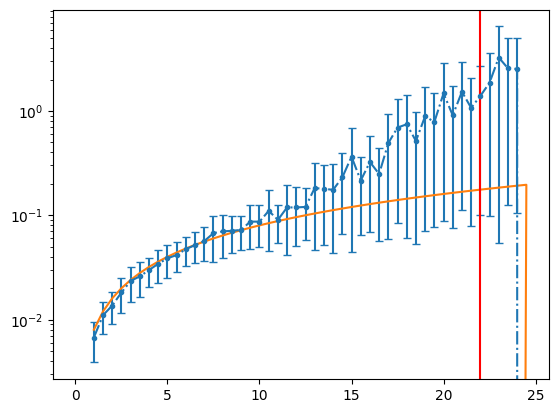

In [ ]:
test = 0.008*betas 
plt.errorbar(betas, data, yerr = data_error, marker = '.', capsize = 3, linestyle = "-.")
plt.plot(betas, test)
plt.yscale("log")
plt.show()

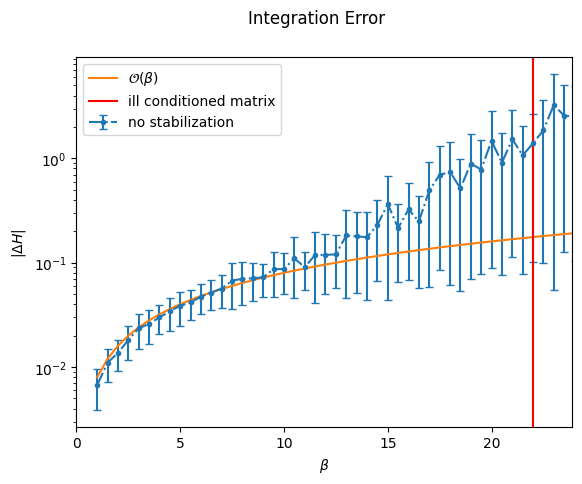

In [28]:
test = 0.008*betas 
plt.errorbar(betas, data, yerr = data_error, marker = '.', capsize = 3, linestyle = "-.", label = 'no stabilization')
plt.suptitle('Integration Error')
plt.plot(betas, test, label = r'$\mathcal{O}(\beta)$')
plt.yscale("log")
plt.axvline(x=22, color = 'red', label = 'ill conditioned matrix')
plt.legend()
plt.xlabel(r'$\beta$')
plt.xlim(0, 23.9)
plt.ylabel(r'$|\Delta H|$')
plt.show()

In [ ]:
# L = 4
# U = 1.0
# Delta = 0.4
# mu = 0.8
# dtau = 0.1
# Ntau = 8
# t_MD = 0.6
# N_MD = 8
# N_therm = 1000
# N_cfg = 5000
# save_frequency = 1
# filename = "test.h5"
# taus = np.arange(0, dtau*(Ntau+1), dtau)

# sim_dict = {"L" : L,
#             "U" : U,
#             "Delta" : Delta,
#             "mu" : mu,
#             "dtau" : dtau,
#             "Ntau" : Ntau,
#             "t_MD" : t_MD,
#             "N_MD" : N_MD,
#             "N_therm" : N_therm,
#             "N_cfg" : N_cfg,
#             "save_frequency" : save_frequency,
#             "filename" : filename
#             }
# try:
#     model = Kitaev_action(L, U, Delta, mu, dtau, Ntau)
#     saver = DataSaver(filename, sim_dict)
#     algorithm = HMC(t_MD, N_MD, model, saver = saver, seed = 3432)

#     generate(algorithm, N_therm, N_cfg, save_frequency)

# except Exception:
#     print("Failure")
#     traceback.print_exc()
#     saver.close()
#     os.remove(filename)
# finally:
#     saver.close()
#     pass


Begin thermilization for 1000 configurations.
Thermilization done after 2.56s!
Begin generation of 5000 configurations.
At sample 1 out of 5000, running since 0.01s!, projected time left: 49.99s
Acceptance rate at 0.5


KeyboardInterrupt: 

In [8]:
binsize = 100
N_boot = 1000

Cm, phases = read_correlator_file(filename, model)
Cd = get_dirac_correlators(Cm)

C_dirac, C_dirac_err, phase_avg, phase_std = bootstrap_reweighting(Cd, phases, binsize, N_boot, model.rng)
print(phase_avg, phase_std)

(0.9076871783203584-0.0003166993597637706j) (0.14093065600433455+0.39527513988679996j)


In [9]:
Ced  = np.load("Data/ed_corr.npy")
taus_ed = np.load('Data/ed_taus.npy')

fig, ax = plt.subplots(L, L, figsize = (L*4.8, L*4.8))
fig.supylabel(r"$C_{ij}(\tau)$")
fig.supxlabel(r"$\tau$")
for x in range(L):
    for y in range(L):
        cax = ax[x, y]
        cax.grid()
        cax.errorbar(taus, C_dirac[x,y,:].real, marker = '.', capsize=3, label = "pfQMC", yerr = np.real(C_dirac_err[x,y,:]), linestyle ="none")
        cax.errorbar(taus_ed, Ced[x,y,:].real,  linestyle = "--", label = "ED")
        cax.set_title(f"(i,j)=({x},{y})")


handles, labels = ax[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.94),
    ncol=2,
)

fig.tight_layout(rect=[0, 0, 1, 0.93])

plt.savefig("Plots/KitaevChain_spatial_corr_pfQMC.png", dpi = 200, bbox_inches = "tight")
plt.close()